In [2]:
import pandas as pd

df = pd.read_csv("../data/data.csv", encoding="ISO-8859-1")

print("Dataset Shape:")
print(df.shape)

df.head()

Dataset Shape:
(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
# Remove rows where CustomerID is missing
df = df.dropna(subset=['CustomerID'])

print("After removing missing CustomerID:")
print(df.shape)

After removing missing CustomerID:
(406829, 8)


In [7]:
# Remove cancelled orders
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print("After removing cancelled orders:")
print(df.shape)

After removing cancelled orders:
(397924, 8)


In [8]:
# Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      397924 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB


In [9]:
# Create Sales column

df['Sales'] = df['Quantity'] * df['UnitPrice']

df[['Quantity','UnitPrice','Sales']].head()

,Quantity,UnitPrice,Sales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


# Data Cleaning Summary

## Steps Performed

1. Loaded the dataset
2. Inspected data structure
3. Checked missing values
4. Removed rows with missing CustomerID
5. Removed cancelled transactions
6. Converted InvoiceDate to datetime format
7. Created Sales column

## Dataset Used

Online Retail Dataset

## Objective

Prepare clean transaction data for Cohort Retention Analysis and Customer Lifetime Value (CLTV) calculations.

In [10]:
# Create Invoice Month

df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

df[['InvoiceDate', 'InvoiceMonth']].head()

,InvoiceDate,InvoiceMonth
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


In [11]:
# Find first purchase month for each customer

cohort_data = df.groupby('CustomerID')['InvoiceMonth'].min().reset_index()

cohort_data.columns = ['CustomerID', 'CohortMonth']

cohort_data.head()

,CustomerID,CohortMonth
0,12346.0,2011-01
1,12347.0,2010-12
2,12348.0,2010-12
3,12349.0,2011-11
4,12350.0,2011-02


In [ ]:
# Merge cohort month into main dataframe

df = df.merge(cohort_data, on='CustomerID')

df[['CustomerID', 'InvoiceMonth', 'CohortMonth']].head()

,CustomerID,InvoiceMonth,CohortMonth
0,17850.0,2010-12,2010-12
1,17850.0,2010-12,2010-12
2,17850.0,2010-12,2010-12
3,17850.0,2010-12,2010-12
4,17850.0,2010-12,2010-12


In [13]:
# Calculate Cohort Index

df['CohortIndex'] = (
    (df['InvoiceMonth'].dt.year - df['CohortMonth'].dt.year) * 12
    + (df['InvoiceMonth'].dt.month - df['CohortMonth'].dt.month)
    + 1
)

df[['CustomerID', 'CohortMonth', 'InvoiceMonth', 'CohortIndex']].head(10)

,CustomerID,CohortMonth,InvoiceMonth,CohortIndex
0,17850.0,2010-12,2010-12,1
1,17850.0,2010-12,2010-12,1
2,17850.0,2010-12,2010-12,1
3,17850.0,2010-12,2010-12,1
4,17850.0,2010-12,2010-12,1
5,17850.0,2010-12,2010-12,1
6,17850.0,2010-12,2010-12,1
7,17850.0,2010-12,2010-12,1
8,17850.0,2010-12,2010-12,1
9,13047.0,2010-12,2010-12,1


In [14]:
# Count unique customers by cohort and cohort index

cohort_counts = (
    df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID']
      .nunique()
      .reset_index()
)

cohort_counts.head(10)

,CohortMonth,CohortIndex,CustomerID
0,2010-12,1,885
1,2010-12,2,324
2,2010-12,3,286
3,2010-12,4,340
4,2010-12,5,321
5,2010-12,6,352
6,2010-12,7,321
7,2010-12,8,309
8,2010-12,9,313
9,2010-12,10,350


In [15]:
retention_matrix = cohort_counts.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerID'
)

retention_matrix

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Convert retention counts to retention percentages

retention_rate = retention_matrix.divide(
    retention_matrix.iloc[:, 0],
    axis=0
)

retention_rate = retention_rate.round(3)

retention_rate

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366,0.323,0.384,0.363,0.398,0.363,0.349,0.354,0.395,0.374,0.503,0.266
2011-01,1.0,0.221,0.266,0.230,0.321,0.288,0.247,0.242,0.300,0.326,0.365,0.118,NaN
2011-02,1.0,0.187,0.187,0.284,0.271,0.247,0.253,0.279,0.247,0.305,0.068,NaN,NaN
2011-03,1.0,0.150,0.252,0.199,0.223,0.168,0.268,0.230,0.279,0.086,NaN,NaN,NaN
2011-04,1.0,0.213,0.203,0.210,0.197,0.227,0.217,0.260,0.073,NaN,NaN,NaN,NaN
2011-05,1.0,0.190,0.173,0.173,0.208,0.232,0.264,0.095,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.174,0.157,0.264,0.231,0.335,0.095,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.181,0.207,0.223,0.271,0.112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.207,0.249,0.243,0.124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


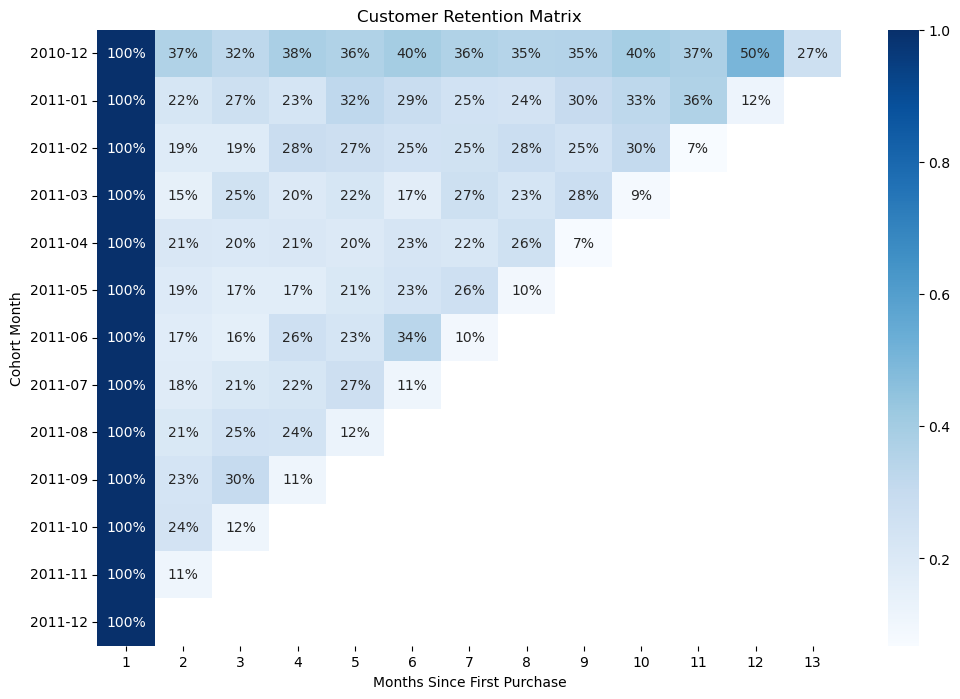

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

sns.heatmap(
    retention_rate,
    annot=True,
    fmt='.0%',
    cmap='Blues'
)

plt.title('Customer Retention Matrix')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')

plt.show()